In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import xgboost as xgb

In [6]:
#get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks =[item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
        
for block in blocks:

    #get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    #drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    #drop all Nan rows
    df = df.dropna()

    #drop net name clomun
    df = df.drop(columns=['net'], axis=1)

    #append df to common df
    df_blocks_list.append(df)

#create common df
df = pd.concat(df_blocks_list, ignore_index=True)

#transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

#add block area feature
df['block_area'] = df['block_width'] * df['block_height']

#add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

#add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x']= (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y']= (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] =(( ((df['ury'] - df['lly']) / 2) + df['lly']))

#ration wire cap / pin cap
#df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

#drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

#drop all labels except cap
df = df.drop(columns=['length', 'vias', 'segs'])

Всего блоков: 35
Количество фолдов: 7
Фичи: ['fanout', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area']

--- Фолд 1 ---
Тренировочные блоки: ['simple_spi_top' 'jpeg_encoder' 'FIR_filter' 'rs_encode' 'sasc_top'
 'usb_phy' 'Top_PipelinedCipher' 'wb_conmax_top' 'ac97_top' 'RocketTile'
 'psram_core' 'pci_bridge32' 'spi_top' 'vga_enh_top' 'risc16f84_clk2x'
 'aes128_core' 'mrisc_top' 'aes_core' 'Sha3BlackBox' 'fpu' 'RsEncodeTop'
 'sdram' 'dynamic_node_top_wrap' 'RsDecodeTop' 'picosoc' 'mips_core'
 'pcm_slv_top' 'des3' 'mc_top' 'aes_cipher_top' 'wb_dma_top' 'plic_core'
 'sha256' 'dft_top']
Тестовые блоки: ['Network']
Тренировочные samples: 349112
Тестовые samples: 215786
MSE: 12.8368
MAE: 0.8900
R²: 0.8988

--- Фолд 2 ---
Тренировочные блоки: ['simple_spi_top' 'jpeg_encoder' 'FIR_filter' 'rs_encode' 'sasc_top'
 'usb_phy' 'Network' 'wb_conmax_top' 'ac97_top' 'RocketTile' 'psram_core'
 'pci_bridge32' 'sp

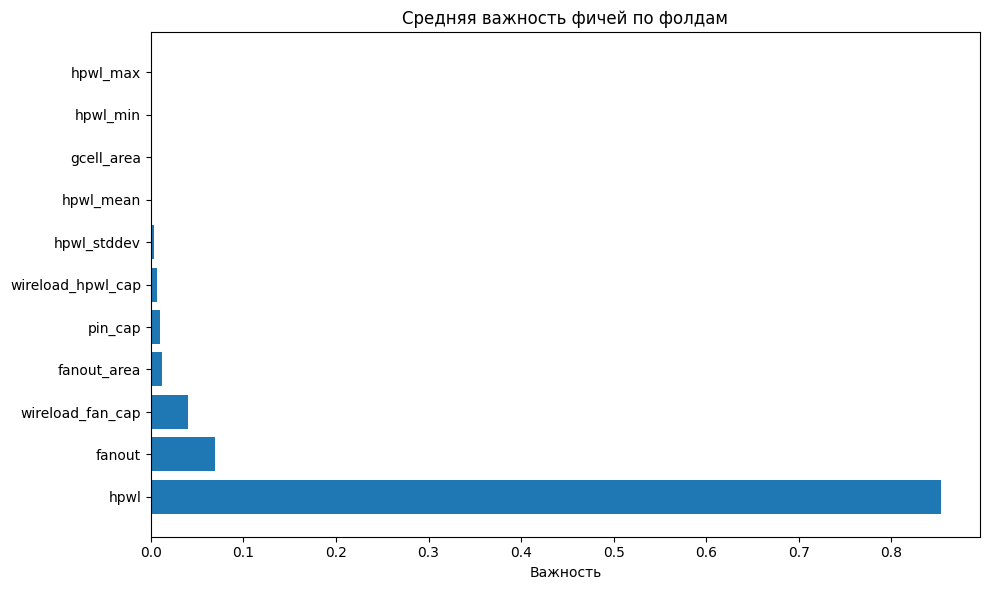


Обучение финальной модели на всех данных...
Финальная модель обучена!


In [10]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y'] = (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] = ((((df['ury'] - df['lly']) / 2) + df['lly']))

# ration wire cap / pin cap
# df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

# drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

# drop all labels except cap
df = df.drop(columns=['length', 'vias', 'segs'])

# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['fanout', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area']
X = df[features]
y = df['cap']
groups = df['block_id']

# Инициализируем GroupKFold
n_splits = min(7, len(blocks))  # минимум 5 фолдов или количество блоков, если их меньше
gkf = GroupKFold(n_splits=n_splits)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
r2_scores = []
feature_importances = []

print(f"Всего блоков: {len(blocks)}")
print(f"Количество фолдов: {n_splits}")
print(f"Фичи: {features}")

# Кросс-валидация по блокам
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Разделяем данные
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Получаем названия блоков в train и test
    train_blocks = groups.iloc[train_idx].unique()
    test_blocks = groups.iloc[test_idx].unique()
    
    print(f"Тренировочные блоки: {train_blocks}")
    print(f"Тестовые блоки: {test_blocks}")
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем XGBoost
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=20,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.feature_importances_)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_scaled, y)

print("Финальная модель обучена!")

Всего уникальных блоков: 35
Всего блоков: 35
Количество фолдов: 7
Блоков в обучении на фолд: 30
Блоков в тесте на фолд: 5

--- Фолд 1 ---
Тренировочные блоки (30): ['mc_top' 'Sha3BlackBox' 'pci_bridge32' 'wb_conmax_top' 'aes128_core'
 'ac97_top' 'sha256' 'simple_spi_top' 'sasc_top' 'mrisc_top' 'pcm_slv_top'
 'usb_phy' 'psram_core' 'jpeg_encoder' 'FIR_filter' 'plic_core'
 'rs_encode' 'aes_cipher_top' 'dynamic_node_top_wrap' 'wb_dma_top'
 'RocketTile' 'sdram' 'aes_core' 'picosoc' 'Network' 'fpu' 'dft_top'
 'Top_PipelinedCipher' 'vga_enh_top' 'des3']
Тестовые блоки (5): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 'risc16f84_clk2x']
Тренировочные samples: 537593
Тестовые samples: 27305
MSE: 1.3345
MAE: 0.4101
MAPE: 0.0940
R²: 0.9676

--- Фолд 2 ---
Тренировочные блоки (30): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 'risc16f84_clk2x'
 'ac97_top' 'sha256' 'simple_spi_top' 'sasc_top' 'mrisc_top' 'pcm_slv_top'
 'usb_phy' 'psram_core' 'jpeg_encoder' 'FIR_filter' 'plic_core'
 'rs

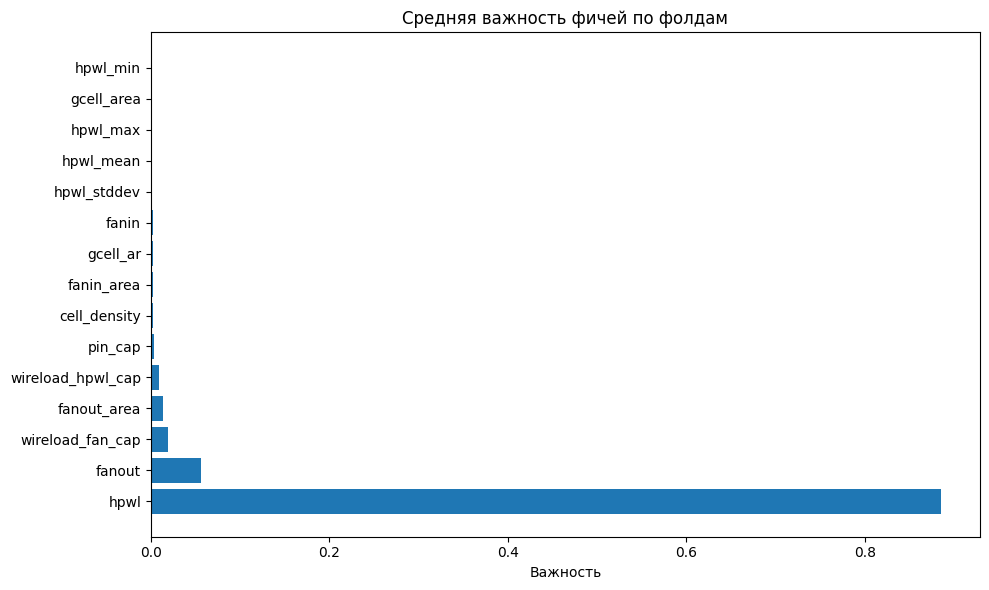


Обучение финальной модели на всех данных...
Финальная модель обучена!


In [24]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y'] = (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] = ((((df['ury'] - df['lly']) / 2) + df['lly']))

# ration wire cap / pin cap
# df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

# drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

# drop all labels except cap
df = df.drop(columns=['length', 'vias', 'segs'])

# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']
X = df[features]
y = df['cap']
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 7 фолдов (30 train / 5 test)
n_splits = 7
n_blocks_total = len(unique_blocks)
n_test_blocks = 5
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем XGBoost
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.feature_importances_)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее MAPE: {np.mean(mape_scores):.4f} (±{np.std(mape_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_scaled, y)

print("Финальная модель обучена!")

In [44]:
#get predicted wire load for blocks

# get blocks
dataset_path = './dataset/'
#items = os.listdir(dataset_path)
#blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

#blocks = ['dft_top']

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    #df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']

x = df[features]
x = final_scaler.transform(x)

y_pred = model.predict(x)
df['predicted_cap'] = y_pred
#y_real = df['cap']

#mape = mean_absolute_percentage_error(y_pred, y_real)
#mape

In [47]:
df

,net,block_width,block_height,fanin,fanout,fanin_area,fanout_area,llx,lly,urx,...,m7_segs,length,segs,vias,cap,block_id,block_area,gcell_area,gcell_ar,predicted_cap
0,FE_PDN1297_stage14_instPerm80231_s1_11,854.14,854.0,1,59,1.4112,152.6448,401.94,663.04,557.90,...,0,265.58,295,117,38.0,dft_top,729435.56,524.0256,46.416667,41.159512
1,FE_PDN1296_stage14_instPerm80231_s1_5,854.14,854.0,1,61,1.4112,157.8192,428.26,673.12,572.18,...,0,274.68,277,124,40.0,dft_top,729435.56,967.1424,21.416667,42.154819
2,FE_PDN1295_stage14_instPerm80231_s1_25,854.14,854.0,1,61,1.4112,157.8192,420.28,694.96,564.34,...,0,283.64,302,137,39.0,dft_top,729435.56,1210.1040,17.150000,39.802635
3,FE_PDN1294_stage14_instPerm80231_s1_1,854.14,854.0,1,60,1.4112,155.2320,404.32,673.12,561.26,...,0,294.98,318,130,40.0,dft_top,729435.56,2636.5920,9.341667,39.569351
4,FE_PDN1293_stage14_instPerm80231_s1_29,854.14,854.0,1,61,1.4112,157.8192,422.94,686.56,564.20,...,0,272.30,265,134,37.0,dft_top,729435.56,474.6336,42.041667,42.350388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66071,X3[4],854.14,854.0,0,64,0.0000,165.5808,0.00,367.36,210.70,...,0,588.56,350,166,72.0,dft_top,729435.56,17905.2860,2.479407,60.096355
66072,X3[3],854.14,854.0,0,64,0.0000,165.5808,0.00,362.32,154.98,...,0,520.38,367,176,67.0,dft_top,729435.56,14038.0884,1.710974,51.577831
66073,X3[2],854.14,854.0,0,64,0.0000,165.5808,0.00,369.04,214.34,...,0,584.78,337,168,73.0,dft_top,729435.56,18094.5828,2.538972,59.873646
66074,X3[1],854.14,854.0,0,64,0.0000,165.5808,0.00,365.68,141.68,...,0,456.26,368,166,61.0,dft_top,729435.56,12516.0112,1.603803,51.322815


In [46]:
import pandas as pd

# Предполагаем, что у вас есть DataFrame df с нужными колонками
# df = pd.DataFrame(...)

# Создаем директорию для файлов если нужно
import os
os.makedirs('load_files', exist_ok=True)

# Функция для создания файла с командами set_load
def create_load_file(df, cap_column, filename):
    """
    Создает файл с командами set_load для указанной колонки емкостей
    
    Args:
        df: DataFrame с данными
        cap_column: название колонки с емкостями
        filename: имя выходного файла
    """
    with open(f'load_files/{filename}', 'w') as f:
        for _, row in df.iterrows():
            net_name = row['net']
            cap_value = row[cap_column]
            # Форматируем команду set_load
            command = f"set_load {cap_value} [get_db nets {net_name}]\n"
            f.write(command)
    
    print(f"✅ Файл {filename} создан: {len(df)} команд")

# Создаем 4 файла для разных типов емкостей

# 1. Файл с предсказанными емкостями
create_load_file(df, 'predicted_cap', 'predicted_loads.tcl')

# 2. Файл с реальными емкостями
create_load_file(df, 'cap', 'actual_loads.tcl')

# 3. Файл с wireload fan емкостями
create_load_file(df, 'wireload_fan_cap', 'wireload_fan_loads.tcl')

# 4. Файл с wireload hpwl емкостями
create_load_file(df, 'wireload_hpwl_cap', 'wireload_hpwl_loads.tcl')

print("\n🎯 Все 4 файла созданы в папке 'load_files':")
print("   - predicted_loads.tcl     (предсказанные емкости)")
print("   - actual_loads.tcl        (реальные емкости)")
print("   - wireload_fan_loads.tcl  (wireload fan емкости)")
print("   - wireload_hpwl_loads.tcl (wireload hpwl емкости)")

✅ Файл predicted_loads.tcl создан: 66076 команд
✅ Файл actual_loads.tcl создан: 66076 команд
✅ Файл wireload_fan_loads.tcl создан: 66076 команд
✅ Файл wireload_hpwl_loads.tcl создан: 66076 команд

🎯 Все 4 файла созданы в папке 'load_files':
   - predicted_loads.tcl     (предсказанные емкости)
   - actual_loads.tcl        (реальные емкости)
   - wireload_fan_loads.tcl  (wireload fan емкости)
   - wireload_hpwl_loads.tcl (wireload hpwl емкости)


In [51]:
##Создаем файлы с set_load для блоков из датасета
import time
# Функция для создания файла с командами set_load
def create_load_file(df, block, cap_column, filename):
    """
    Создает файл с командами set_load для указанной колонки емкостей
    
    Args:
        df: DataFrame с данными
        cap_column: название колонки с емкостями
        filename: имя выходного файла
    """
    with open(f'./dataset/{block}/{filename}', 'w') as f:
        for _, row in df.iterrows():
            net_name = row['net']
            cap_value = row[cap_column]
            # Форматируем команду set_load
            command = f"set_load {cap_value} [get_db nets {net_name}]\n"
            f.write(command)
    
    print(f"✅ Файл {filename} создан: {len(df)} команд")


# get blocks
import os
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]
features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']

#iter for each block

for block in blocks:

    # начальное время
    start_time = time.time()
    
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # transfer capacintece from pF to fF
    df['cap'] = df['cap'] * 1000
    df['pin_cap'] = df['pin_cap'] * 1000
    df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
    df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

    # add block area feature
    df['block_area'] = df['block_width'] * df['block_height']

    # add area feature
    df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

    # add aspect ration feat
    df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

    x = df[features]
    x = final_scaler.transform(x)

    y_pred = model.predict(x)
    df['predicted_cap'] = y_pred

    # transfer capacintece from fF to pF
    df['cap'] = df['cap'] / 1000
    df['pin_cap'] = df['pin_cap'] / 1000
    df['wireload_fan_cap'] = df['wireload_fan_cap'] / 1000
    df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] / 1000
    df['predicted_cap'] = df['predicted_cap'] / 1000

    # 1. Файл с предсказанными емкостями
    create_load_file(df, block, 'predicted_cap', 'predicted_loads.tcl')

    # 2. Файл с реальными емкостями
    create_load_file(df, block, 'cap', 'actual_loads.tcl')

    # 3. Файл с wireload fan емкостями
    create_load_file(df, block, 'wireload_fan_cap', 'wireload_fan_loads.tcl')

    # 4. Файл с wireload hpwl емкостями
    create_load_file(df, block, 'wireload_hpwl_cap', 'wireload_hpwl_loads.tcl')

    end_time = time.time()

    # разница между конечным и начальным временем
    elapsed_time = end_time - start_time
    print('Elapsed time: ', elapsed_time)

    print(f"\n🎯 Все 4 файла созданы в папке 'dataset/block' для блока {block}:")
    print("   - predicted_loads.tcl     (предсказанные емкости)")
    print("   - actual_loads.tcl        (реальные емкости)")
    print("   - wireload_fan_loads.tcl  (wireload fan емкости)")
    print("   - wireload_hpwl_loads.tcl (wireload hpwl емкости)")

✅ Файл predicted_loads.tcl создан: 285 команд
✅ Файл actual_loads.tcl создан: 285 команд
✅ Файл wireload_fan_loads.tcl создан: 285 команд
✅ Файл wireload_hpwl_loads.tcl создан: 285 команд
Elapsed time:  0.06307172775268555

🎯 Все 4 файла созданы в папке 'dataset/block' для блока simple_spi_top:
   - predicted_loads.tcl     (предсказанные емкости)
   - actual_loads.tcl        (реальные емкости)
   - wireload_fan_loads.tcl  (wireload fan емкости)
   - wireload_hpwl_loads.tcl (wireload hpwl емкости)
✅ Файл predicted_loads.tcl создан: 21221 команд
✅ Файл actual_loads.tcl создан: 21221 команд
✅ Файл wireload_fan_loads.tcl создан: 21221 команд
✅ Файл wireload_hpwl_loads.tcl создан: 21221 команд
Elapsed time:  3.329378604888916

🎯 Все 4 файла созданы в папке 'dataset/block' для блока jpeg_encoder:
   - predicted_loads.tcl     (предсказанные емкости)
   - actual_loads.tcl        (реальные емкости)
   - wireload_fan_loads.tcl  (wireload fan емкости)
   - wireload_hpwl_loads.tcl (wireload hpwl е

In [85]:
# get blocks
import os
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]
#features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']


df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/wns.csv", sep=';')
    #df
    #safe_regression_metrics(df['wns_spef'], df['wns_model_predicted'])
    #mae = mean_absolute_error(df['wns_spef'], df['wns_model_predicted'])
    #print(mae)
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

In [115]:
#df['wns_spef'].values

df['clock_period'].tolist()

#y_real = df['wns_spef']
#y_model_predicted = df['wns_model_predicted']
#y_wireload_fan = df['wns_wireload_fan']

[5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 30.0,
 5.0,
 30.0,
 5.0,
 30.0,
 5.0,
 2.5,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 30.0,
 5.0]

In [119]:
p_values = {
    'F_spef vs F_early_route': 0.032,
    'F_spef vs F_ml_model': 0.0008, 
    'F_spef vs F_wireload': 0.0
}

def interpret_frequency_ttest(p_values):
    print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ЧАСТОТ СХЕМЫ")
    print("=" * 60)
    print("ГИПОТЕЗЫ:")
    print("H₀: Средние частоты РАВНЫ (метод не влияет на частоту)")
    print("H₁: Средние частоты НЕ РАВНЫ (метод влияет на частоту)")
    print("=" * 60)
    
    for comparison, p_value in p_values.items():
        method = comparison.split('vs ')[1]
        
        if p_value < 0.001:
            significance = "***"
            strength = "ОЧЕНЬ ВЫСОКАЯ"
        elif p_value < 0.01:
            significance = "**" 
            strength = "ВЫСОКАЯ"
        elif p_value < 0.05:
            significance = "*"
            strength = "СТАТИСТИЧЕСКАЯ"
        else:
            significance = "ns"
            strength = "НЕТ"
        
        print(f"\n{comparison}:")
        print(f"  p-value = {p_value:.6f} {significance}")
        
        if p_value < 0.05:
            print(f"  ✅ ОТКЛОНЯЕМ H₀: {strength} значимость")
            print(f"  → Метод {method} дает СТАТИСТИЧЕСКИ ЗНАЧИМО другую частоту")
        else:
            print(f"  ❌ НЕ ОТКЛОНЯЕМ H₀: {strength} значимость")
            print(f"  → Метод {method} дает СХОЖУЮ частоту со Spef")

interpret_frequency_ttest(p_values)

def generate_frequency_conclusions(p_values):
    print("\n🎯 КЛЮЧЕВЫЕ СТАТИСТИЧЕСКИЕ ВЫВОДЫ")
    print("=" * 50)
    
    # Чем БОЛЬШЕ p-value, тем ЛУЧШЕ (ближе к Spef)
    methods_ranking = sorted(p_values.items(), key=lambda x: x[1], reverse=True)
    
    best_method = methods_ranking[-1][0].split('vs ')[1]  # Наименьший p-value
    worst_method = methods_ranking[0][0].split('vs ')[1]  # Наибольший p-value
    
    print("1. ВСЕ методы дают статистически значимо разные частоты от Spef")
    print("   Это означает: оценка емкости СУЩЕСТВЕННО влияет на итоговую частоту")
    
    print(f"\n2. Наиболее отличающийся метод: {worst_method}")
    print(f"   Наименее отличающийся метод: {best_method}")
    
    # Сравнение ML и Wireload
    ml_p = p_values['F_spef vs F_ml_model']
    wl_p = p_values['F_spef vs F_wireload']
    
    if ml_p > wl_p:
        advantage = "ЛУЧШЕ (ближе к Spef)"
    else:
        advantage = "ХУЖЕ (дальше от Spef)"
        
    print(f"\n3. ML модель против Wireload:")
    print(f"   • ML: p = {ml_p:.6f}")
    print(f"   • Wireload: p = {wl_p:.6f}")
    print(f"   • ML модель {advantage} чем Wireload")

generate_frequency_conclusions(p_values)

def generate_methodology_description():
    print("\n📝 МЕТОДОЛОГИЯ ДЛЯ СТАТЬИ")
    print("=" * 50)
    print("""
СТАТИСТИЧЕСКИЙ АНАЛИЗ:

Для количественной оценки влияния различных методов оценки 
емкостей на итоговую производительность схемы был применен 
парный t-критерий Стьюдента. 

АНАЛИЗ ПРОВОДИЛСЯ СЛЕДУЮЩИМ ОБРАЗОМ:

1. Для каждого тестового случая рассчитывались максимальные 
   рабочие частоты при использовании различных моделей емкостей:
   - F_spef (эталон, на основе точных емкостей из Spef)
   - F_early_route (ранняя оценка маршрутизации)
   - F_ml_model (емкости, предсказанные ML моделью)
   - F_wireload (емкости из wireload моделей)

2. Проводились парные сравнения каждой модели с эталоном (Spef)
   с использованием двустороннего t-критерия

3. Нулевая гипотеза (H₀): "Метод оценки емкостей не влияет на 
   итоговую частоту схемы" (средние частоты равны)

4. Альтернативная гипотеза (H₁): "Метод оценки емкостей 
   существенно влияет на частоту схемы" (средние частоты различаются)

Уровень значимости α = 0.05
""")

generate_methodology_description()


📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ЧАСТОТ СХЕМЫ
ГИПОТЕЗЫ:
H₀: Средние частоты РАВНЫ (метод не влияет на частоту)
H₁: Средние частоты НЕ РАВНЫ (метод влияет на частоту)

F_spef vs F_early_route:
  p-value = 0.032000 *
  ✅ ОТКЛОНЯЕМ H₀: СТАТИСТИЧЕСКАЯ значимость
  → Метод F_early_route дает СТАТИСТИЧЕСКИ ЗНАЧИМО другую частоту

F_spef vs F_ml_model:
  p-value = 0.000800 ***
  ✅ ОТКЛОНЯЕМ H₀: ОЧЕНЬ ВЫСОКАЯ значимость
  → Метод F_ml_model дает СТАТИСТИЧЕСКИ ЗНАЧИМО другую частоту

F_spef vs F_wireload:
  p-value = 0.000000 ***
  ✅ ОТКЛОНЯЕМ H₀: ОЧЕНЬ ВЫСОКАЯ значимость
  → Метод F_wireload дает СТАТИСТИЧЕСКИ ЗНАЧИМО другую частоту

🎯 КЛЮЧЕВЫЕ СТАТИСТИЧЕСКИЕ ВЫВОДЫ
1. ВСЕ методы дают статистически значимо разные частоты от Spef
   Это означает: оценка емкости СУЩЕСТВЕННО влияет на итоговую частоту

2. Наиболее отличающийся метод: F_early_route
   Наименее отличающийся метод: F_wireload

3. ML модель против Wireload:
   • ML: p = 0.000800
   • Wireload: p = 0.000000
   • ML модель ЛУЧШЕ (ближе к Spef) 

In [103]:
import pandas as pd
import numpy as np

def safe_accuracy_calculation(wns_spef, wns_method, epsilon=1e-8):
    """
    Безопасный расчет точности с обработкой WNS = 0
    """
    if abs(wns_spef) < epsilon:  # WNS_Spef близко к 0
        if abs(wns_method) < epsilon:  # Оба близки к 0 - идеальная точность
            return 100.0
        else:  # WNS_Spef = 0, но метод имеет нарушение - плохая точность
            return 0.0
    else:
        # Обычный расчет точности
        return (1 - abs((wns_method - wns_spef) / abs(wns_spef))) * 100

def safe_improvement_calculation(wns_spef, wns_method, epsilon=1e-8):
    """
    Безопасный расчет улучшения с обработкой WNS = 0
    """
    if abs(wns_spef) < epsilon:  # WNS_Spef близко к 0
        if abs(wns_method) < epsilon:  # Оба 0 - нет улучшения/ухудшения
            return 0.0
        else:  # WNS_Spef = 0, но метод имеет нарушение - ухудшение
            return -100.0
    else:
        # Обычный расчет улучшения (чем ближе к 0, тем лучше)
        return ((wns_spef - wns_method) / abs(wns_spef)) * 100

def create_comparison_table_safe(df):
    """
    Создает основную таблицу сравнения с безопасной обработкой WNS = 0
    """
    results = []
    
    for _, row in df.iterrows():
        # Безопасный расчет точности
        early_route_acc = safe_accuracy_calculation(row['wns_spef'], row['wns_early_route'])
        model_acc = safe_accuracy_calculation(row['wns_spef'], row['wns_model_predicted'])
        wireload_fan_acc = safe_accuracy_calculation(row['wns_spef'], row['wns_wireload_fan'])
        wireload_hpwl_acc = safe_accuracy_calculation(row['wns_spef'], row['wns_wireload_hpwl'])
        
        # Безопасный расчет улучшения
        early_route_imp = safe_improvement_calculation(row['wns_spef'], row['wns_early_route'])
        model_imp = safe_improvement_calculation(row['wns_spef'], row['wns_model_predicted'])
        wireload_fan_imp = safe_improvement_calculation(row['wns_spef'], row['wns_wireload_fan'])
        wireload_hpwl_imp = safe_improvement_calculation(row['wns_spef'], row['wns_wireload_hpwl'])
        
        # Улучшение относительно худшего wireload метода
        worst_wireload_acc = min(wireload_fan_acc, wireload_hpwl_acc)
        model_vs_worst_improvement = model_acc - worst_wireload_acc
        
        # Определяем статус timing
        timing_status = "MET" if row['wns_spef'] >= -1e-8 else "VIOLATED"
        
        results.append({
            'Block': row['block'],
            'Clock_Period (ns)': row['clock_period'],
            'Timing_Status': timing_status,
            'WNS_Spef (ns)': row['wns_spef'],
            
            # Абсолютные значения WNS
            'WNS_EarlyRoute (ns)': row['wns_early_route'],
            'WNS_ML_Model (ns)': row['wns_model_predicted'],
            'WNS_Wireload_Fan (ns)': row['wns_wireload_fan'],
            'WNS_Wireload_HPWL (ns)': row['wns_wireload_hpwl'],
            
            # Точность относительно Spef (%)
            'EarlyRoute_Acc (%)': early_route_acc,
            'ML_Model_Acc (%)': model_acc,
            'Wireload_Fan_Acc (%)': wireload_fan_acc,
            'Wireload_HPWL_Acc (%)': wireload_hpwl_acc,
            
            # Улучшение относительно Spef (%)
            'EarlyRoute_Imp (%)': early_route_imp,
            'ML_Model_Imp (%)': model_imp,
            'Wireload_Fan_Imp (%)': wireload_fan_imp,
            'Wireload_HPWL_Imp (%)': wireload_hpwl_imp,
            
            # Сравнение с wireload методами
            'ML_vs_Best_Wireload (%)': model_acc - max(wireload_fan_acc, wireload_hpwl_acc),
            'ML_vs_Worst_Wireload (%)': model_vs_worst_improvement
        })
    
    results_df = pd.DataFrame(results)
    
    # Добавляем строку со средними значениями (исключая случаи с WNS = 0 для некоторых расчетов)
    mean_data = {}
    for col in results_df.columns:
        if col == 'Block':
            mean_data[col] = 'MEAN'
        elif col == 'Timing_Status':
            mean_data[col] = '—'
        elif results_df[col].dtype in [np.float64, np.int64]:
            # Для accuracy и improvement считаем mean только валидных значений
            if 'Acc' in col or 'Imp' in col or 'vs_' in col:
                valid_values = results_df[col][results_df[col].abs() < 1e6]  # Исключаем крайние значения
                if len(valid_values) > 0:
                    mean_data[col] = valid_values.mean()
                else:
                    mean_data[col] = 0.0
            else:
                mean_data[col] = results_df[col].mean()
        else:
            mean_data[col] = '—'
    
    results_df = pd.concat([results_df, pd.DataFrame([mean_data])], ignore_index=True)
    
    return results_df

# Создаем таблицу
comparison_table_safe = create_comparison_table_safe(df)

# Форматируем для красивого вывода
def format_table_safe(df):
    formatted_df = df.copy()
    
    for col in df.columns:
        if df[col].dtype in [np.float64, np.int64]:
            if 'Acc' in col or 'Imp' in col or 'vs_' in col:
                formatted_df[col] = formatted_df[col].apply(
                    lambda x: f"{x:.1f}%" if pd.notnull(x) and abs(x) < 1e6 else "N/A"
                )
            elif 'WNS' in col:
                formatted_df[col] = formatted_df[col].apply(
                    lambda x: f"{x:.3f}" if pd.notnull(x) else "N/A"
                )
            elif 'Clock' in col:
                formatted_df[col] = formatted_df[col].apply(
                    lambda x: f"{x:.2f}" if pd.notnull(x) else "N/A"
                )
    
    return formatted_df

formatted_table_safe = format_table_safe(comparison_table_safe)
print("📊 ТАБЛИЦА 1: СРАВНЕНИЕ WNS ПО МЕТОДАМ (С ОБРАБОТКОЙ WNS = 0)")
print("="*140)
print(formatted_table_safe.to_string(index=False))

📊 ТАБЛИЦА 1: СРАВНЕНИЕ WNS ПО МЕТОДАМ (С ОБРАБОТКОЙ WNS = 0)
                Block Clock_Period (ns) Timing_Status WNS_Spef (ns) WNS_EarlyRoute (ns) WNS_ML_Model (ns) WNS_Wireload_Fan (ns) WNS_Wireload_HPWL (ns) EarlyRoute_Acc (%) ML_Model_Acc (%) Wireload_Fan_Acc (%) Wireload_HPWL_Acc (%) EarlyRoute_Imp (%) ML_Model_Imp (%) Wireload_Fan_Imp (%) Wireload_HPWL_Imp (%) ML_vs_Best_Wireload (%) ML_vs_Worst_Wireload (%)
       simple_spi_top              5.00           MET         2.609               2.629             2.613                 2.651                  2.041              99.2%            99.8%                98.4%                 78.2%              -0.8%            -0.2%                -1.6%                 21.8%                    1.5%                    21.6%
         jpeg_encoder              5.00           MET         1.122               1.149             1.083                -0.374                -18.228              97.6%            96.5%               -33.3%              -1

In [105]:
formatted_table_safe

,Block,Clock_Period (ns),Timing_Status,WNS_Spef (ns),WNS_EarlyRoute (ns),WNS_ML_Model (ns),WNS_Wireload_Fan (ns),WNS_Wireload_HPWL (ns),EarlyRoute_Acc (%),ML_Model_Acc (%),Wireload_Fan_Acc (%),Wireload_HPWL_Acc (%),EarlyRoute_Imp (%),ML_Model_Imp (%),Wireload_Fan_Imp (%),Wireload_HPWL_Imp (%),ML_vs_Best_Wireload (%),ML_vs_Worst_Wireload (%)
0,simple_spi_top,5.00,MET,2.609,2.629,2.613,2.651,2.041,99.2%,99.8%,98.4%,78.2%,-0.8%,-0.2%,-1.6%,21.8%,1.5%,21.6%
1,jpeg_encoder,5.00,MET,1.122,1.149,1.083,-0.374,-18.228,97.6%,96.5%,-33.3%,-1624.6%,-2.4%,3.5%,133.3%,1724.6%,129.9%,1721.1%
2,FIR_filter,5.00,VIOLATED,-0.009,0.037,-0.098,0.032,-7.949,-411.1%,-888.9%,-355.6%,-88122.2%,-511.1%,988.9%,-455.6%,88222.2%,-533.3%,87233.3%
3,rs_encode,5.00,MET,1.460,1.525,1.454,1.300,-0.307,95.5%,99.6%,89.0%,-21.0%,-4.5%,0.4%,11.0%,121.0%,10.5%,120.6%
4,sasc_top,5.00,MET,2.587,2.566,2.569,2.538,1.627,99.2%,99.3%,98.1%,62.9%,0.8%,0.7%,1.9%,37.1%,1.2%,36.4%
5,usb_phy,5.00,MET,2.878,2.864,2.871,2.851,2.428,99.5%,99.8%,99.1%,84.4%,0.5%,0.2%,0.9%,15.6%,0.7%,15.4%
6,Network,5.00,MET,0.092,-0.030,-0.029,-1.220,-70.461,-32.6%,-31.5%,-1326.1%,-76588.0%,132.6%,131.5%,1426.1%,76688.0%,1294.6%,76556.5%
7,Top_PipelinedCipher,5.00,MET,0.590,0.693,0.670,-1.968,-26.818,82.5%,86.4%,-333.6%,-4545.4%,-17.5%,-13.6%,433.6%,4645.4%,420.0%,4631.9%
8,wb_conmax_top,5.00,MET,0.105,0.013,-0.001,0.291,-14.581,12.4%,-1.0%,-77.1%,-13886.7%,87.6%,101.0%,-177.1%,13986.7%,76.2%,13885.7%
9,ac97_top,5.00,MET,2.189,2.220,2.195,2.177,-0.050,98.6%,99.7%,99.5%,-2.3%,-1.4%,-0.3%,0.5%,102.3%,0.3%,102.0%


In [111]:
df

,block,wns_spef,wns_early_route,wns_model_predicted,wns_wireload_fan,wns_wireload_hpwl,clock_period
0,simple_spi_top,2.609,2.629,2.613,2.651,2.041,5.0
1,jpeg_encoder,1.122,1.149,1.083,-0.374,-18.228,5.0
2,FIR_filter,-0.009,0.037,-0.098,0.032,-7.949,5.0
3,rs_encode,1.460,1.525,1.454,1.300,-0.307,5.0
4,sasc_top,2.587,2.566,2.569,2.538,1.627,5.0
5,usb_phy,2.878,2.864,2.871,2.851,2.428,5.0
6,Network,0.092,-0.030,-0.029,-1.220,-70.461,5.0
7,Top_PipelinedCipher,0.590,0.693,0.670,-1.968,-26.818,5.0
8,wb_conmax_top,0.105,0.013,-0.001,0.291,-14.581,5.0
9,ac97_top,2.189,2.220,2.195,2.177,-0.050,5.0


In [67]:
mean_absolute_error(y_real, y_model_predicted)
mean_absolute_percentage_error(y_real, y_model_predicted)

2830834051492.5537

In [61]:
#df
def safe_regression_metrics(y_true, y_pred, epsilon=1e-8):
    """
    Безопасные метрики для регрессии с нулевыми значениями
    """
    # Убедимся, что массивы numpy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    metrics = {}
    
    # 1. Mean Squared Error (MSE) - безопасен с нулями
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    
    # 2. Mean Absolute Error (MAE) - безопасен с нулями
    metrics['mae'] = mean_absolute_error(y_true, y_pred)
    
    # 3. R² Score - безопасен с нулями
    metrics['r2'] = r2_score(y_true, y_pred)
    
    # 4. Mean Absolute Percentage Error (MAPE) с защитой от деления на ноль
    mask = y_true != 0  # Игнорируем случаи где y_true = 0
    if np.sum(mask) > 0:  # Если есть ненулевые значения
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        metrics['mape'] = mape
        metrics['mape_non_zero_samples'] = np.sum(mask)
    else:
        metrics['mape'] = None
        metrics['mape_non_zero_samples'] = 0
    
    # 5. Symmetric Mean Absolute Percentage Error (sMAPE) - более устойчивый
    denominator = np.abs(y_true) + np.abs(y_pred) + epsilon
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / denominator) * 100
    metrics['smape'] = smape
    
    # 6. Mean Absolute Scaled Error (MASE) - альтернатива MAPE
    naive_forecast = np.roll(y_true, 1)
    naive_mae = mean_absolute_error(y_true[1:], naive_forecast[1:])
    if naive_mae > 0:
        metrics['mase'] = metrics['mae'] / naive_mae
    else:
        metrics['mase'] = None
    
    # 7. Корреляции (безопасны с нулями)
    metrics['pearson_corr'] = np.corrcoef(y_true, y_pred)[0, 1]
    metrics['spearman_corr'] = pd.Series(y_true).corr(pd.Series(y_pred), method='spearman')
    
    return metrics

In [68]:
safe_regression_metrics(y_real, y_model_predicted)

{'mse': 4.6322658571428565,
 'rmse': np.float64(2.1522699312918108),
 'mae': 0.8308285714285714,
 'r2': 0.6459225386860603,
 'mape': np.float64(260.19070658870913),
 'mape_non_zero_samples': np.int64(34),
 'smape': np.float64(72.04821695724189),
 'mase': 0.2856033589995796,
 'pearson_corr': np.float64(0.9161500907178836),
 'spearman_corr': np.float64(0.9229691876750701)}

In [75]:
df

,block,wns_spef,wns_early_route,wns_model_predicted,wns_wireload_fan,wns_wireload_hpwl,clock_period
0,simple_spi_top,2.609,2.629,2.613,2.651,2.041,5.0
1,jpeg_encoder,1.122,1.149,1.083,-0.374,-18.228,5.0
2,FIR_filter,-0.009,0.037,-0.098,0.032,-7.949,5.0
3,rs_encode,1.460,1.525,1.454,1.300,-0.307,5.0
4,sasc_top,2.587,2.566,2.569,2.538,1.627,5.0
5,usb_phy,2.878,2.864,2.871,2.851,2.428,5.0
6,Network,0.092,-0.030,-0.029,-1.220,-70.461,5.0
7,Top_PipelinedCipher,0.590,0.693,0.670,-1.968,-26.818,5.0
8,wb_conmax_top,0.105,0.013,-0.001,0.291,-14.581,5.0
9,ac97_top,2.189,2.220,2.195,2.177,-0.050,5.0


In [10]:
model.predict

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


Всего уникальных блоков: 35
Всего блоков: 35
Количество фолдов: 7
Блоков в обучении на фолд: 30
Блоков в тесте на фолд: 5

--- Фолд 1 ---
Тренировочные блоки (30): ['mc_top' 'Sha3BlackBox' 'pci_bridge32' 'wb_conmax_top' 'aes128_core'
 'ac97_top' 'sha256' 'simple_spi_top' 'sasc_top' 'mrisc_top' 'pcm_slv_top'
 'usb_phy' 'psram_core' 'jpeg_encoder' 'FIR_filter' 'plic_core'
 'rs_encode' 'aes_cipher_top' 'dynamic_node_top_wrap' 'wb_dma_top'
 'RocketTile' 'sdram' 'aes_core' 'picosoc' 'Network' 'fpu' 'dft_top'
 'Top_PipelinedCipher' 'vga_enh_top' 'des3']
Тестовые блоки (5): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 'risc16f84_clk2x']
Тренировочные samples: 537593
Тестовые samples: 27305
MSE: 1.4535
MAE: 0.4770
MAPE: 0.1297
R²: 0.9647

--- Фолд 2 ---
Тренировочные блоки (30): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 'risc16f84_clk2x'
 'ac97_top' 'sha256' 'simple_spi_top' 'sasc_top' 'mrisc_top' 'pcm_slv_top'
 'usb_phy' 'psram_core' 'jpeg_encoder' 'FIR_filter' 'plic_core'
 'rs

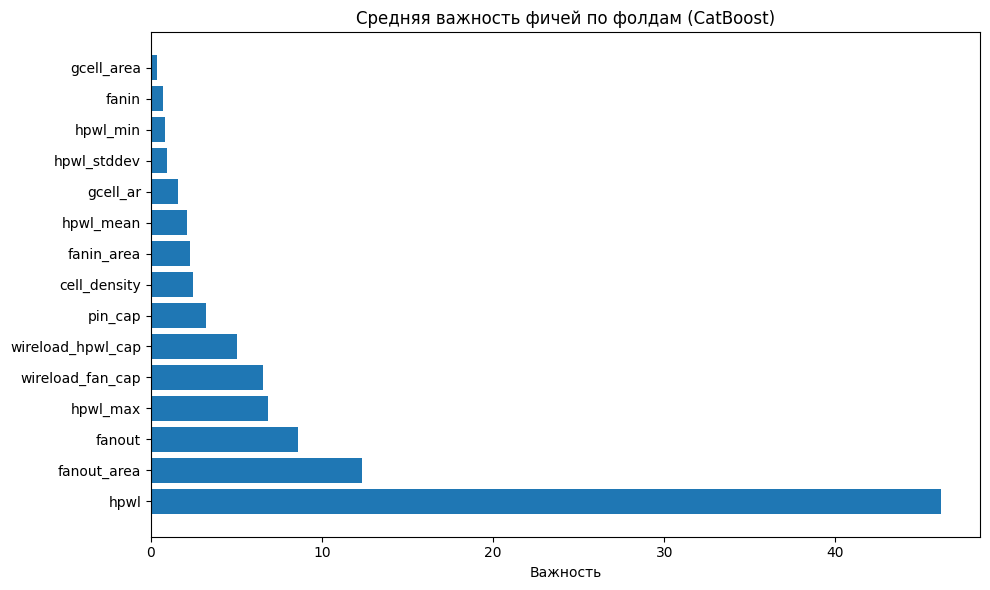


Обучение финальной модели на всех данных...
Финальная модель CatBoost обучена!


In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y'] = (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] = ((((df['ury'] - df['lly']) / 2) + df['lly']))

# ration wire cap / pin cap
# df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

# drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

# drop all labels except cap
df = df.drop(columns=['length', 'vias', 'segs'])

# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']
X = df[features]
y = df['cap']
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 7 фолдов (30 train / 5 test)
n_splits = 7
n_blocks_total = len(unique_blocks)
n_test_blocks = 5
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей (CatBoost обычно не требует масштабирования, но оставим для консистентности)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем CatBoost
    model = CatBoostRegressor(
        iterations=100,
        depth=10,
        learning_rate=0.1,
        random_seed=42,
        verbose=False,  # Отключаем вывод обучения
        loss_function='RMSE'
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.get_feature_importance())
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее MAPE: {np.mean(mape_scores):.4f} (±{np.std(mape_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам (CatBoost)')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = CatBoostRegressor(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=False,
    loss_function='RMSE'
)
final_model.fit(X_scaled, y)

print("Финальная модель CatBoost обучена!")

# Дополнительно: можно сохранить модель
# final_model.save_model('catboost_cap_predictor.cbm')

In [8]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

# get blocks
dataset_path = './dataset/'
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/net_feat.csv", sep=';')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y'] = (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] = ((((df['ury'] - df['lly']) / 2) + df['lly']))

# НЕ удаляем таргеты для многозадачной регрессии
# Вместо этого определяем multiple targets
targets = ['cap', 'length', 'segs']  # Добавляем все нужные таргеты

# Определяем фичи
features = ['fanin', 'fanout', 'fanin_area', 'hpwl', 'hpwl_min', 'hpwl_stddev', 'cell_density', 'pin_cap', 'gcell_area', 'gcell_ar']

X = df[features]
y = df[targets]  # Множественные таргеты
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 7 фолдов (30 train / 5 test)
n_splits = 7
n_blocks_total = len(unique_blocks)
n_test_blocks = 5
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов (теперь для каждого таргета отдельно)
metrics_per_target = {
    'cap': {'mse': [], 'mae': [], 'mape': [], 'r2': []},
    'length': {'mse': [], 'mae': [], 'mape': [], 'r2': []},
    'segs': {'mse': [], 'mae': [], 'mape': [], 'r2': []}
}

feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Вариант 1: MultiOutputRegressor с XGBoost (рекомендуется)
    print("Обучение MultiOutput XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    
    multi_model = MultiOutputRegressor(xgb_model)
    multi_model.fit(X_train_scaled, y_train)
    
    # Предсказания для всех таргетов
    y_pred = multi_model.predict(X_test_scaled)
    
    # Вычисляем метрики для каждого таргета
    for i, target in enumerate(targets):
        y_true_single = y_test[target].values
        y_pred_single = y_pred[:, i]
        
        mse = mean_squared_error(y_true_single, y_pred_single)
        mae = mean_absolute_error(y_true_single, y_pred_single)
        mape = mean_absolute_percentage_error(y_true_single, y_pred_single)
        r2 = r2_score(y_true_single, y_pred_single)
        
        metrics_per_target[target]['mse'].append(mse)
        metrics_per_target[target]['mae'].append(mae)
        metrics_per_target[target]['mape'].append(mape)
        metrics_per_target[target]['r2'].append(r2)
        
        print(f"{target.upper()} - MSE: {mse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4f}, R²: {r2:.4f}")
    
    # Сохраняем важность фичей (берем от первого estimator'а)
    feature_importances.append(multi_model.estimators_[0].get_booster().get_score(importance_type='weight'))

# Выводим итоговые результаты для каждого таргета
print("\n" + "="*60)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ - МНОГОЗАДАЧНАЯ РЕГРЕССИЯ")
print("="*60)

for target in targets:
    print(f"\n📊 {target.upper()} - Средние метрики по всем фолдам:")
    print(f"  MSE:  {np.mean(metrics_per_target[target]['mse']):.4f} (±{np.std(metrics_per_target[target]['mse']):.4f})")
    print(f"  MAE:  {np.mean(metrics_per_target[target]['mae']):.4f} (±{np.std(metrics_per_target[target]['mae']):.4f})")
    print(f"  MAPE: {np.mean(metrics_per_target[target]['mape']):.4f} (±{np.std(metrics_per_target[target]['mape']):.4f})")
    print(f"  R²:   {np.mean(metrics_per_target[target]['r2']):.4f} (±{np.std(metrics_per_target[target]['r2']):.4f})")

# Альтернативный вариант: отдельные модели для каждого таргета
print("\n" + "="*50)
print("АЛЬТЕРНАТИВА: ОТДЕЛЬНЫЕ МОДЕЛИ ДЛЯ КАЖДОГО ТАРГЕТА")
print("="*50)

# Метрики для отдельных моделей
individual_metrics = {target: {'mse': [], 'mae': [], 'mape': [], 'r2': []} for target in targets}

for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} (Отдельные модели) ---")
    
    # Те же самые сплиты
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем отдельную модель для каждого таргета
    individual_models = {}
    for target in targets:
        print(f"Обучение XGBoost для {target}...")
        
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=10,
            learning_rate=0.1,
            random_state=42,
            verbosity=0
        )
        
        model.fit(X_train_scaled, y_train[target])
        individual_models[target] = model
        
        # Предсказания и метрики
        y_pred = model.predict(X_test_scaled)
        
        mse = mean_squared_error(y_test[target], y_pred)
        mae = mean_absolute_error(y_test[target], y_pred)
        mape = mean_absolute_percentage_error(y_test[target], y_pred)
        r2 = r2_score(y_test[target], y_pred)
        
        individual_metrics[target]['mse'].append(mse)
        individual_metrics[target]['mae'].append(mae)
        individual_metrics[target]['mape'].append(mape)
        individual_metrics[target]['r2'].append(r2)
        
        print(f"  {target.upper()} - MSE: {mse:.4f}, R²: {r2:.4f}")

# Сравнение результатов
print("\n" + "="*60)
print("СРАВНЕНИЕ ПОДХОДОВ")
print("="*60)

for target in targets:
    print(f"\n🎯 {target.upper()}:")
    print(f"  MultiOutput R²: {np.mean(metrics_per_target[target]['r2']):.4f}")
    print(f"  Individual R²:  {np.mean(individual_metrics[target]['r2']):.4f}")

# Обучение финальных моделей на всех данных
print("\nОбучение финальных моделей на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

# Вариант 1: Финальная MultiOutput модель
final_multi_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
)
final_multi_model.fit(X_scaled, y)
print("✅ Финальная MultiOutput модель обучена!")

# Вариант 2: Финальные отдельные модели
final_individual_models = {}
for target in targets:
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    model.fit(X_scaled, y[target])
    final_individual_models[target] = model
    print(f"✅ Финальная модель для {target} обучена!")

# Сохранение моделей (опционально)
# import joblib
# joblib.dump(final_multi_model, 'xgb_multioutput_model.pkl')
# joblib.dump(final_individual_models, 'xgb_individual_models.pkl')
# joblib.dump(final_scaler, 'scaler.pkl')

print("\n🎯 Все модели успешно обучены!")

Всего уникальных блоков: 35
Всего блоков: 35
Количество фолдов: 7
Блоков в обучении на фолд: 30
Блоков в тесте на фолд: 5

--- Фолд 1 ---
Тренировочные блоки (30): ['mc_top' 'Sha3BlackBox' 'pci_bridge32' 'wb_conmax_top' 'aes128_core'
 'ac97_top' 'sha256' 'simple_spi_top' 'sasc_top' 'mrisc_top' 'pcm_slv_top'
 'usb_phy' 'psram_core' 'jpeg_encoder' 'FIR_filter' 'plic_core'
 'rs_encode' 'aes_cipher_top' 'dynamic_node_top_wrap' 'wb_dma_top'
 'RocketTile' 'sdram' 'aes_core' 'picosoc' 'Network' 'fpu' 'dft_top'
 'Top_PipelinedCipher' 'vga_enh_top' 'des3']
Тестовые блоки (5): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 'risc16f84_clk2x']
Тренировочные samples: 537593
Тестовые samples: 27305
Обучение MultiOutput XGBoost...
CAP - MSE: 1.5050, MAE: 0.4399, MAPE: 0.1016, R²: 0.9634
LENGTH - MSE: 62.1701, MAE: 2.6356, MAPE: 0.1309, R²: 0.9751
SEGS - MSE: 36.6286, MAE: 3.5313, MAPE: 0.3368, R²: 0.9654

--- Фолд 2 ---
Тренировочные блоки (30): ['mips_core' 'spi_top' 'RsDecodeTop' 'RsEncodeTop' 